This notebook is used to compare the model predictions from each iteration of each model. The hypothesis is that by the final iteration (most training data) all of the predictions will be the same or very similiar.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob
import mat73

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat
from matplotlib.animation import FuncAnimation

2026-07-27 11:32:16.802510: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Load Data

In [16]:
# original data on transect 7.3
path_norm=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/transect7_3_norm.csv"
path=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/transect_7_3.csv"

transect73_norm=pd.read_csv(path_norm)
transect73=pd.read_csv(path)

In [3]:
# L2R model
path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration1_transects_norm.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration2_transects_norm.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration3_transects_norm.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration4_transects_norm.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration5_transects_norm.csv"

nit1_L2R=pd.read_csv(path1)
nit2_L2R=pd.read_csv(path2)
nit3_L2R=pd.read_csv(path3)
nit4_L2R=pd.read_csv(path4)
nit5_L2R=pd.read_csv(path5)

path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration1_transects.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration2_transects.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration3_transects.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration4_transects.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration5_transects.csv"

it1_L2R=pd.read_csv(path1)
it2_L2R=pd.read_csv(path2)
it3_L2R=pd.read_csv(path3)
it4_L2R=pd.read_csv(path4)
it5_L2R=pd.read_csv(path5)

In [4]:
# R2L model
path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration1_transects_norm.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration2_transects_norm.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration3_transects_norm.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration4_transects_norm.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration5_transects_norm.csv"

nit1_R2L=pd.read_csv(path1)
nit2_R2L=pd.read_csv(path2)
nit3_R2L=pd.read_csv(path3)
nit4_R2L=pd.read_csv(path4)
nit5_R2L=pd.read_csv(path5)

path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration1_transects.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration2_transects.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration3_transects.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration4_transects.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/R2L_buildingUp/iteration5_transects.csv"

it1_R2L=pd.read_csv(path1)
it2_R2L=pd.read_csv(path2)
it3_R2L=pd.read_csv(path3)
it4_R2L=pd.read_csv(path4)
it5_R2L=pd.read_csv(path5)

In [5]:
# alt mdoel
path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration1_transects_norm.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration2_transects_norm.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration3_transects_norm.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration4_transects_norm.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration5_transects_norm.csv"

nit1_alt=pd.read_csv(path1)
nit2_alt=pd.read_csv(path2)
nit3_alt=pd.read_csv(path3)
nit4_alt=pd.read_csv(path4)
nit5_alt=pd.read_csv(path5)

path1=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration1_transects.csv"
path2=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration2_transects.csv"
path3=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration3_transects.csv"
path4=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration4_transects.csv"
path5=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/alt_buildingUp/iteration5_transects.csv"

it1_alt=pd.read_csv(path1)
it2_alt=pd.read_csv(path2)
it3_alt=pd.read_csv(path3)
it4_alt=pd.read_csv(path4)
it5_alt=pd.read_csv(path5)

In [6]:
def save_comp_video_animation(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    model_names,  # e.g., ('L2R','R2L',..)
    iteration, # string of iteratio number
    stage_dir="stage_outputs",
    interval=500
):
    """
    Creates and saves a dynamic video tracking 3 different profile repairs over time
    across the entire cross-shore profile (no dune offset).
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    orig_full_data = orig_full_df.values
    recon1_data = recon1_df.values
    recon2_data = recon2_df.values
    recon3_data = recon3_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(10, 4))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    #ax.set_ylim(0,1)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1,5)# np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Cross-shore index")
    ax.set_ylabel("Elevation (m)")
   
    # Initialize baseline handles
    #line_orig, = ax.plot([], [], color='peachpuff', alpha=0.6, linewidth=1.5, label='Original Data')
   
    # 3 Reconstruction Lines
    line_recon1, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{model_names[0]} Reconstruction')
    line_recon2, = ax.plot([], [], color='darkorange', linewidth=2, label=f'MAE-{model_names[1]} Reconstruction')
    line_recon3, = ax.plot([], [], color='mediumpurple', linewidth=2, label=f'MAE-{model_names[2]} Reconstruction')
    line_orig, = ax.plot([], [], color='black', alpha=0.6, linewidth=1.5, label='Original Data')

    # Gaps as highlights patch for legend
    gap_patch = plt.Rectangle((0,0), 1, 1, fc="gray", alpha=0.3, label='Gaps')
   
    # Include all lines in the legend
    ax.legend(handles=[line_orig, line_recon1, line_recon2, line_recon3, gap_patch], bbox_to_anchor=(0.5,-0.15),ncol=2)
    #ax.legend(handles=[line_orig, line_recon1, line_recon2, gap_patch], loc='lower left')
    plt.tight_layout()

    gap_spans = []

    def update(frame):
        nonlocal gap_spans
        # Clear previous frame's gap highlights
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
       
        y_orig = orig_full_data[:, frame]
       
        # Direct assignment (no stitching needed)
        y_recon1_full = recon1_data[:, frame]
        y_recon2_full = recon2_data[:, frame]
        y_recon3_full = recon3_data[:, frame]


        # Calculate gaps based on the entire original survey data
        is_gap = np.isnan(y_orig)

        if np.any(is_gap):
            diff = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff == 1)[0] + 1
            gap_ends = np.where(diff == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                span = ax.axvspan(start, end, color='gray', alpha=0.25, zorder=0)
                gap_spans.append(span)

        # Update line data for all 4 profiles
        
        line_recon1.set_data(x_coords, y_recon1_full)
        line_recon2.set_data(x_coords, y_recon2_full)
        line_recon3.set_data(x_coords, y_recon3_full)

        line_orig.set_data(x_coords, y_orig)
       
        ax.set_title(f"Comparison of Full Reconstructions | Timestep: {frame}")
       
        return [line_recon1, line_recon2,line_orig] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"compare_Models_training_iterations{iteration}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

In [7]:
def save_norm_comp_video_animation(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    iteration,
    model_names,  # e.g., ('L2R','R2L',..)
    stage_dir="stage_outputs",
    interval=500
):
    """
    Creates and saves a dynamic video tracking 3 different profile repairs over time
    across the entire cross-shore profile (no dune offset).
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    orig_full_data = orig_full_df.values
    recon1_data = recon1_df.values
    recon2_data = recon2_df.values
    recon3_data = recon3_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(10, 4))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    #ax.set_ylim(0,1)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1,0.8)# np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Cross-shore index")
    ax.set_ylabel("Normalized Elevation (m)")
   
    # Initialize baseline handles
    #line_orig, = ax.plot([], [], color='peachpuff', alpha=0.6, linewidth=1.5, label='Original Data')
   
    # 3 Reconstruction Lines
    line_recon1, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{model_names[0]} Reconstruction')
    line_recon2, = ax.plot([], [], color='darkorange', linewidth=2, label=f'MAE-{model_names[1]} Reconstruction')
    line_recon3, = ax.plot([], [], color='mediumpurple', linewidth=2, label=f'MAE-{model_names[2]} Reconstruction')
 
    line_orig, = ax.plot([], [], color='black', alpha=0.6, linewidth=1.5, label='Original Data')

    # Gaps as highlights patch for legend
    gap_patch = plt.Rectangle((0,0), 1, 1, fc="gray", alpha=0.3, label='Gaps')
   
    # Include all lines in the legend
    ax.legend(handles=[line_orig, line_recon1, line_recon2, line_recon3, gap_patch], bbox_to_anchor=(0.5,-0.15),ncol=2)
    #ax.legend(handles=[line_orig, line_recon1, line_recon2, gap_patch], loc='lower left')
    plt.tight_layout()

    gap_spans = []

    def update(frame):
        nonlocal gap_spans
        # Clear previous frame's gap highlights
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
       
        y_orig = orig_full_data[:, frame]
       
        # Direct assignment (no stitching needed)
        y_recon1_full = recon1_data[:, frame]
        y_recon2_full = recon2_data[:, frame]
        y_recon3_full = recon3_data[:, frame]

        # Calculate gaps based on the entire original survey data
        is_gap = np.isnan(y_orig)

        if np.any(is_gap):
            diff = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff == 1)[0] + 1
            gap_ends = np.where(diff == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                span = ax.axvspan(start, end, color='gray', alpha=0.25, zorder=0)
                gap_spans.append(span)

        # Update line data for all 4 profiles
        
        line_recon1.set_data(x_coords, y_recon1_full)
        line_recon2.set_data(x_coords, y_recon2_full)
        line_recon3.set_data(x_coords, y_recon3_full)
        line_orig.set_data(x_coords, y_orig)
       
        ax.set_title(f"Comparison of Full Reconstructions | Timestep: {frame}")
       
        return [line_recon1, line_recon2,line_orig] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"compare_norm_training_iterations{iteration}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

In [8]:
def save_compstats_video_animation(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    iteration,
    model_names,  # e.g., ('L2R','R2L',..)
    stage_dir="stage_outputs",
    interval=500
):
    """
    Creates and saves a dynamic video tracking 3 different profile repairs over time
    across the entire cross-shore profile (no dune offset).
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    orig_full_data = orig_full_df.values
    recon1_data = recon1_df.values
    recon2_data = recon2_df.values
    recon3_data = recon3_df.values

    all_its=np.array([recon1_data,recon2_data,recon3_data])

    mean_recon=np.mean(all_its,axis=0)
    std_recon=np.std(all_its,axis=0)
    min_recon=np.min(all_its,axis=0)
    max_recon=np.max(all_its,axis=0)
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(10, 4))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    #ax.set_ylim(0,1)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1,5)# np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Cross-shore index")
    ax.set_ylabel("Elevation (m)")
   
    # Initialize baseline handles
    #line_orig, = ax.plot([], [], color='peachpuff', alpha=0.6, linewidth=1.5, label='Original Data')
   
    # 3 Reconstruction Lines
    #line_recon1, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{model_names[0]} Reconstruction')
    #ine_recon2, = ax.plot([], [], color='darkorange', linewidth=2, label=f'MAE-{model_names[1]} Reconstruction')
    #line_recon3, = ax.plot([], [], color='gold', linewidth=2, label=f'MAE-{model_names[2]} Reconstruction')
    #line_recon4, = ax.plot([], [], color='springgreen', linewidth=2, label=f'MAE-{model_names[3]} Reconstruction')
    #line_recon5, = ax.plot([], [], color='skyblue', linewidth=2, label=f'MAE-{model_names[4]} Reconstruction')
    line_mean,=ax.plot([],[],color='deeppink',linewidth=2,label='Iterations Mean')
    line_orig, = ax.plot([], [], color='black', alpha=0.6, linewidth=1.5, label='Original Data')

    # Gaps as highlights patch for legend
    gap_patch, =ax.plot([],[],color='gray',alpha=0.25,label='Gaps') #plt.Rectangle((0,0), 1, 1, fc="gray", alpha=0.3, label='Gaps')
    gap_spans = []

    fill_container=[]
    from matplotlib.patches import Patch
    spread_patch=Patch(color='blue',alpha=0.3, label='Iteration Range')
    gap_patch=Patch(color='gray',alpha=0.25,label='Gaps')
   
    # Include all lines in the legend
    ax.legend(handles=[line_orig, line_mean, spread_patch, gap_patch], bbox_to_anchor=(0.5,-0.15),ncol=2)
    #ax.legend(handles=[line_orig, line_recon1, line_recon2, gap_patch], loc='lower left')
    plt.tight_layout()

    def update(frame):
        nonlocal gap_spans,fill_container
        if fill_container:
            fill_container[0].remove()
            fill_container.clear()

        # Clear previous frame's gap highlights
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
       
        y_orig = orig_full_data[:, frame]
       
        frame_recons=all_its[:,:,frame]
        y_mean=np.mean(frame_recons,axis=0)
        y_min=np.min(frame_recons,axis=0)
        y_max=np.max(frame_recons,axis=0)

        poly=ax.fill_between(x_coords,y_min,y_max,color='blue',alpha=0.3,zorder=1)
        fill_container.append(poly)

        # Calculate gaps based on the entire original survey data
        is_gap = np.isnan(y_orig)

        if np.any(is_gap):
            diff = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff == 1)[0] + 1
            gap_ends = np.where(diff == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                span = ax.axvspan(start, end, color='gray', alpha=0.25, zorder=0)
                gap_spans.append(span)

        # Update line data for all 4 profiles
        
        line_mean.set_data(x_coords,y_mean)
        line_orig.set_data(x_coords, y_orig)
       
        ax.set_title(f"Comparison of Full Reconstructions | Timestep: {frame}")
       
        return [line_mean,line_orig] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"compare_stats_iterations{iteration}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

In [9]:
import seaborn as sns

def save_reconstruction_disagreement_heatmap(
    orig_full_df,
    recon1_df,
    recon2_df,
    recon3_df,
    stage_dir="stage_outputs",
    filename="model_disagreement_heatmap.png"
):
    """
    Generates a 2D space-time heatmap showing model disagreement (Standard Deviation
    across 5 reconstructions) across cross-shore points and timesteps, with missing
    data gaps highlighted.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    # 1. Stack all reconstructions into a 3D array: (5, n_points, n_timesteps)
    all_recons = np.stack([
        recon1_df.values,
        recon2_df.values,
        recon3_df.values,
    ], axis=0)
   
    orig_data = orig_full_df.values  # Shape: (n_points, n_timesteps)
   
    # 2. Compute pixel-by-pixel disagreement across the 5 models
    # Resulting shape: (n_points, n_timesteps)
    model_std = np.std(all_recons, axis=0)
   
    # 3. Create the plot
    fig, ax = plt.subplots(figsize=(12, 6))
    x_labels=orig_full_df.columns.tolist()
    y_labels=orig_full_df.index.tolist()

    x_step=max(1,len(x_labels)//5)
    y_step=max(1,len(y_labels)//5)
   
    # Plot heatmap (Y-axis = Cross-shore position, X-axis = Timestep)
    sns.heatmap(
        model_std,
        cmap="magma",                  # Bright colors (yellow/white) = high disagreement
        cbar_kws={'label': 'Model Disagreement Std Dev (m)'},
        xticklabels=x_labels,
        yticklabels=y_labels,
        ax=ax
    )
   
    # 4. Overlay missing data gaps from original profile (mask out missing region in gray)
    is_gap = np.isnan(orig_data)
    if np.any(is_gap):
        # Create a masked overlay where gap points are drawn as semi-transparent gray
        gap_mask = np.ma.masked_where(~is_gap, is_gap)
        ax.imshow(
            gap_mask,
            cmap="Greys",
            alpha=0.3,
            aspect="auto",
            origin="upper",
            zorder=3
        )

    ax.set_xticks(np.arange(0,len(x_labels),x_step))
    ax.set_yticks(np.arange(0,len(y_labels),y_step))

    ax.set_xticklabels(x_labels[::x_step],rotation=45,ha='right')
    ax.set_yticklabels(y_labels[::y_step],rotation=0)

    ax.set_title("Disagreement over  Space & Time", fontsize=14, pad=12)
    ax.set_xlabel("Timestep", fontsize=12)
    ax.set_ylabel("Cross-shore Index", fontsize=12)
   
    plt.tight_layout()
   
    # 5. Save output
    output_path = os.path.join(stage_dir, filename)
    plt.savefig(output_path, dpi=300)
    plt.close()
   

In [10]:
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/comparing_model_iterations"
# iteration 1
save_norm_comp_video_animation(orig_full_df=transect73_norm,recon1_df=nit1_L2R,recon2_df=nit1_R2L,recon3_df=nit1_alt,iteration='1',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_comp_video_animation(orig_full_df=transect73,recon1_df=it1_L2R,recon2_df=it1_R2L,recon3_df=it1_alt,iteration='1',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_compstats_video_animation(orig_full_df=transect73,recon1_df=it1_L2R,recon2_df=it1_R2L,recon3_df=it1_alt,iteration='1',model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)
save_reconstruction_disagreement_heatmap(
    orig_full_df=transect73.iloc[200:],
    recon1_df=it1_L2R.iloc[200:],
    recon2_df=it1_R2L.iloc[200:],
    recon3_df=it1_alt.iloc[200:],
    stage_dir=savepath,
    filename="model_disagreement_heatmap_it1.png"
)

# iteration 2
save_norm_comp_video_animation(orig_full_df=transect73_norm,recon1_df=nit2_L2R,recon2_df=nit2_R2L,recon3_df=nit2_alt,iteration='2',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_comp_video_animation(orig_full_df=transect73,recon1_df=it2_L2R,recon2_df=it2_R2L,recon3_df=it2_alt,iteration='2',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_compstats_video_animation(orig_full_df=transect73,recon1_df=it2_L2R,recon2_df=it2_R2L,recon3_df=it2_alt,iteration='2',model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)
save_reconstruction_disagreement_heatmap(
    orig_full_df=transect73.iloc[200:],
    recon1_df=it2_L2R.iloc[200:],
    recon2_df=it2_R2L.iloc[200:],
    recon3_df=it2_alt.iloc[200:],
    stage_dir=savepath,
    filename="model_disagreement_heatmap_it2.png"
)
# iteration 3
save_norm_comp_video_animation(orig_full_df=transect73_norm,recon1_df=nit3_L2R,recon2_df=nit3_R2L,recon3_df=nit3_alt,iteration='3',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_comp_video_animation(orig_full_df=transect73,recon1_df=it3_L2R,recon2_df=it3_R2L,recon3_df=it3_alt,iteration='3',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_compstats_video_animation(orig_full_df=transect73,recon1_df=it3_L2R,recon2_df=it3_R2L,recon3_df=it3_alt,iteration='3',model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)
save_reconstruction_disagreement_heatmap(
    orig_full_df=transect73.iloc[200:],
    recon1_df=it3_L2R.iloc[200:],
    recon2_df=it3_R2L.iloc[200:],
    recon3_df=it3_alt.iloc[200:],
    stage_dir=savepath,
    filename="model_disagreement_heatmap_it3.png"
)
#iteration 4
save_norm_comp_video_animation(orig_full_df=transect73_norm,recon1_df=nit4_L2R,recon2_df=nit4_R2L,recon3_df=nit4_alt,iteration='4',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_comp_video_animation(orig_full_df=transect73,recon1_df=it4_L2R,recon2_df=it4_R2L,recon3_df=it4_alt,iteration='4',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_compstats_video_animation(orig_full_df=transect73,recon1_df=it4_L2R,recon2_df=it4_R2L,recon3_df=it4_alt,iteration='4',model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)
save_reconstruction_disagreement_heatmap(
    orig_full_df=transect73.iloc[200:],
    recon1_df=it4_L2R.iloc[200:],
    recon2_df=it4_R2L.iloc[200:],
    recon3_df=it4_alt.iloc[200:],
    stage_dir=savepath,
    filename="model_disagreement_heatmap_it4.png"
)
# iteration 5
save_norm_comp_video_animation(orig_full_df=transect73_norm,recon1_df=nit5_L2R,recon2_df=nit5_R2L,recon3_df=nit5_alt,iteration='5',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_comp_video_animation(orig_full_df=transect73,recon1_df=it5_L2R,recon2_df=it5_R2L,recon3_df=it5_alt,iteration='5',model_names=['L2R','R2L','alternating'],stage_dir=savepath,interval=500)
save_compstats_video_animation(orig_full_df=transect73,recon1_df=it5_L2R,recon2_df=it5_R2L,recon3_df=it5_alt,iteration='5',model_names=['1','2','3','4','5'],stage_dir=savepath,interval=500)
save_reconstruction_disagreement_heatmap(
    orig_full_df=transect73.iloc[200:],
    recon1_df=it5_L2R.iloc[200:],
    recon2_df=it5_R2L.iloc[200:],
    recon3_df=it5_alt.iloc[200:],
    stage_dir=savepath,
    filename="model_disagreement_heatmap_it5.png"
)

([<matplotlib.axis.XTick at 0x16121a220>,
 [Text(1, 0, '2-1'), Text(2, 0, '3-2'), Text(3, 0, '4-3'), Text(4, 0, '5-4')])

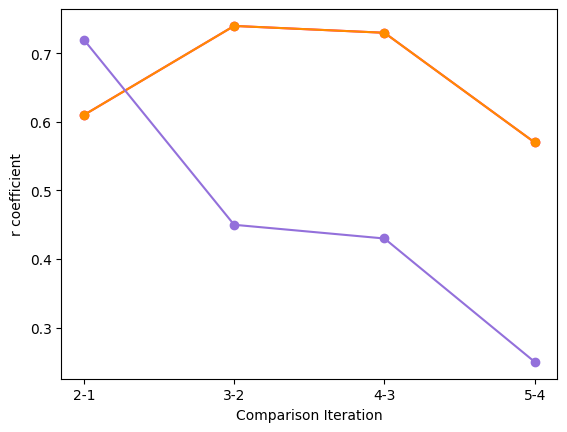

In [13]:
# from coherence calc
x=[1,2,3,4]
L2R_r=[0.61,0.74,0.73,0.57]
R2L_r=[0.61,0.74,0.73,0.57]
ALT_r=[0.72,0.45,0.43,0.25]

plt.plot(x,L2R_r,color='deeppink',marker='o')
plt.plot(x,R2L_r,color='darkorange',marker='o')
plt.plot(x,ALT_r,color='mediumpurple',marker='o')

plt.xlabel('Comparison Iteration')
plt.ylabel('r coefficient')

plt.xticks([1,2,3,4],['2-1','3-2','4-3','5-4'])

In [14]:
from matplotlib.animation import FuncAnimation
def save_consecutive_diff_animation(orig_full_df,
    recon_dfs,
    model_names=('1', '2', '3', '4', '5'),
    stage_dir="stage_outputs",
    filename="consecutive_iteration_diffs.gif",
    interval=500
):
    """
    Creates and saves an animation tracking step-by-step changes
    between consecutive model iterations (e.g., 2 - 1, 3 - 2, 4 - 3, 5 - 4).

    Parameters:
    -----------
    recon_dfs : list of pandas.DataFrame
        List of DataFrames in chronological iteration order [recon1, recon2, recon3, recon4, recon5].
    model_names : tuple or list of str
        Names corresponding to each iteration DataFrame.
    stage_dir : str
        Directory to save the animation.
    filename : str
        Output file name.
    interval : int
        Delay between animation frames in milliseconds.
    """
    os.makedirs(stage_dir, exist_ok=True)
    orig_data=orig_full_df.values

    # Convert all DataFrames to numpy arrays
    data_list = [df.values for df in recon_dfs]
    num_models = len(data_list)

    if num_models < 2:
        raise ValueError("At least 2 model DataFrames are required to calculate differences.")

    n_points, n_timesteps = data_list[0].shape
    x_coords = np.arange(n_points)

    # 1. Compute consecutive pairwise differences: Data[i] - Data[i-1]
    diff_matrices = [data_list[i] - data_list[i - 1] for i in range(1, num_models)]
    diff_labels = [f"{model_names[i]} − {model_names[i-1]}" for i in range(1, num_models)]

    # 2. Set symmetric Y-limits centered around zero based on global maximum step change
    global_max_abs = np.nanmax([np.abs(diff) for diff in diff_matrices])
    bound = global_max_abs * 1.1 if not np.isnan(global_max_abs) else 1.0

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_xlim(0, n_points)
    ax.set_ylim(-bound, bound)
    ax.set_xlabel("Cross-shore index")
    ax.set_ylabel("Reconstruction Difference (m)")

    # Reference baseline (Zero change)
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6, label="No Change (Δ = 0)")

    # Color palette matching consecutive steps
    colors = ['indigo', 'mediumpurple', 'dodgerblue', 'cyan', 'mintcream']
    lines = []

    for i, label in enumerate(diff_labels):
        line, = ax.plot([], [], color=colors[i % len(colors)], linewidth=2, label=label)
        lines.append(line)

    gap_patch = plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.3, label="Gaps")

    # Legend layout
    ax.legend(handles=lines + [gap_patch], loc="lower right", bbox_to_anchor=(1.0, 1.02), ncol=3)
    plt.tight_layout()

    gap_spans = []

    def update(frame):
        nonlocal gap_spans
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
        y_orig=orig_data[:,frame]
        # Identify missing data across all model iterations for this frame
        is_gap = np.isnan(y_orig)

        if np.any(is_gap):
            diff = np.diff(is_gap.astype(int))
            gap_starts = np.where(diff == 1)[0] + 1
            gap_ends = np.where(diff == -1)[0] + 1

            if is_gap[0]:
                gap_starts = np.insert(gap_starts, 0, 0)
            if is_gap[-1]:
                gap_ends = np.append(gap_ends, n_points - 1)

            for start, end in zip(gap_starts, gap_ends):
                span = ax.axvspan(start, end, color="gray", alpha=0.25, zorder=0)
                gap_spans.append(span)

        # Update step difference lines
        for i, line in enumerate(lines):
            line.set_data(x_coords, diff_matrices[i][:, frame])

        ax.set_title(f"Differences between iterations | Timestep: {frame}")
        return lines + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=False)

    video_path = os.path.join(stage_dir, filename)
    anim.save(video_path, writer="pillow")
    plt.close()

    print(f"Animation successfully saved to: {video_path}")


In [19]:
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/comparing_model_iterations"

In [22]:
recon_dfs = [it1_L2R, it2_R2L]
model_names = ('Iter 1 L2R', 'Iter 1 R2L')

save_consecutive_diff_animation(transect73,
    recon_dfs=recon_dfs,
    model_names=model_names,
    stage_dir=savepath,
    filename="iteration_progression_deltas_L2RvR2L1.gif",
    interval=500
)

Animation successfully saved to: /Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/comparing_model_iterations/iteration_progression_deltas_L2RvR2L1.gif


In [23]:
recon_dfs = [it2_L2R, it2_R2L]
model_names = ('Iter 2 L2R', 'Iter 2 R2L')

save_consecutive_diff_animation(transect73,
    recon_dfs=recon_dfs,
    model_names=model_names,
    stage_dir=savepath,
    filename="iteration_progression_deltas_L2RvR2L2.gif",
    interval=500
)

Animation successfully saved to: /Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/comparing_model_iterations/iteration_progression_deltas_L2RvR2L2.gif
